In [ ]:
import sys
import os

# Add project root to sys.path so solar_car can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import liionpack as lp
import pybamm
import numpy as np
import time as ticker
from tqdm import tqdm
from solar_car.battery import SolarCarBatteryManager


lp.set_logging_level("DEBUG")

# Define parameters
Np = 1  # number of parallel cells
Ns = 32  # number of series cells
Nspm = Np * Ns
Iapp = 20

# Generate the netlist
netlist = lp.setup_circuit(Np=Np, Ns=Ns, V=3.6, I=40)

# Define additional output variables
output_variables = [
    "X-averaged negative particle surface concentration [mol.m-3]",
]

# Define the PyBaMM parameters
parameter_values = pybamm.ParameterValues("Chen2020")
parameter_values = pybamm.ParameterValues({
    **parameter_values,
    # cell
    "Nominal cell capacity [A.h]": 5.0 * 9,
    "Contact resistance [Ohm]": 0,
    "Cell cooling surface area [m2]": 0.104,
    "Cell volume [m3]": 0.00208,
    "Cell thermal expansion coefficient [m.K-1]": 1.1e-06,
    # separator
    "Separator porosity": 0.47,
    "Separator Bruggeman coefficient (electrolyte)": 1.5,
    "Separator density [kg.m-3]": 397.0,
    "Separator specific heat capacity [J.kg-1.K-1]": 700.0,
    "Separator thermal conductivity [W.m-1.K-1]": 0.16,
    # sim
    "Reference temperature [K]": 298.15,
    "Ambient temperature [K]": 298.15,
    "Initial temperature [K]": 298.15,
    "Lower voltage cut-off [V]": 2.5,
    "Upper voltage cut-off [V]": 5,
    "Open-circuit voltage at 0% SOC [V]": 2.5,
    "Open-circuit voltage at 100% SOC [V]": 3.6,
    # random guess from Chat
    "Total heat transfer coefficient [W.m-2.K-1]": 5.53,

})


T0 = parameter_values["Initial temperature [K]"]

inputs = {}
input_temperature = np.ones(Nspm) * T0
inputs.update({"Input temperature [K]": input_temperature})
# Solve the pack

rm = SolarCarBatteryManager()
rm.solve(
    netlist=netlist,
    sim_func=lp.basic_simulation,
    parameter_values=parameter_values,
    output_variables=output_variables,
    inputs=None,
    nproc=1,
    initial_soc=1,
    setup_only=True,
    minSteps=100
)


def external_stepper(manager, T0):
    tic = ticker.time()
    # Do stepping
    lp.logger.notice("Starting step solve")
    vlims_ok = True
    input_temperature = np.ones(Nspm) * T0

    with tqdm(total=manager.Nsteps, desc="Stepping simulation") as pbar:
        step = 0
        manager.step = 0
        while step < manager.Nsteps  and vlims_ok:
            manager.protocol[step] = 40
            vlims_ok = manager._step(step, None)
            rm.step = step
            step += 1
            pbar.update(1)


    manager.step = step
    toc = ticker.time()
    lp.logger.notice("Step solve finished")
    lp.logger.notice("Total stepping time " + str(np.around(toc - tic, 3)) + "s")
    lp.logger.notice(
        "Time per step " + str(np.around((toc - tic) / manager.Nsteps, 3)) + "s"
    )


external_stepper(rm, T0)
output = rm.step_output()
for k in output:
    output[k] = output[k][0:-1]



Stepping simulation:  64%|██████▍   | 64/100 [00:07<00:04,  8.51it/s]Event: Maximum voltage [V], Batteries: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 2

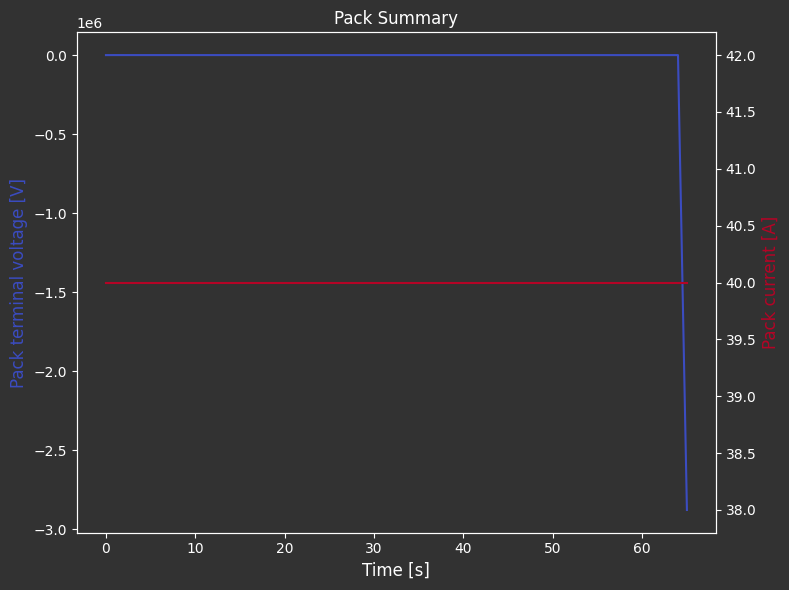

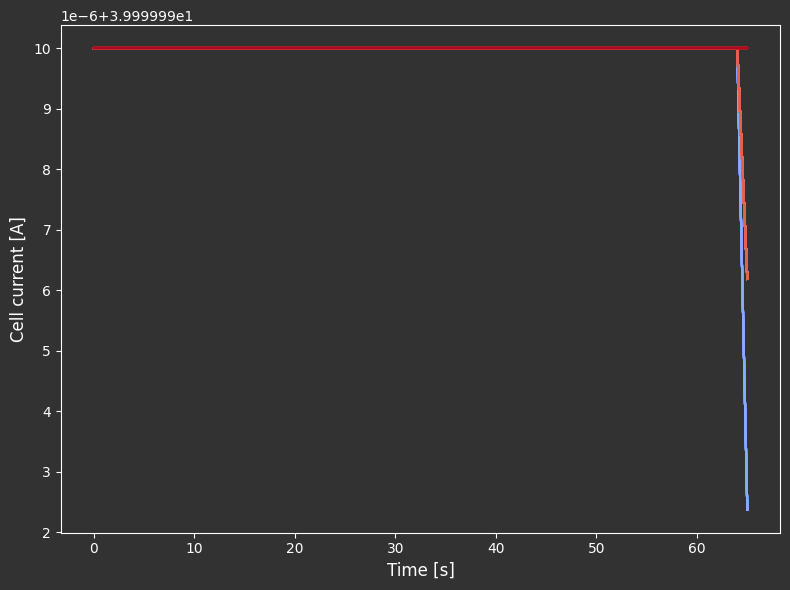

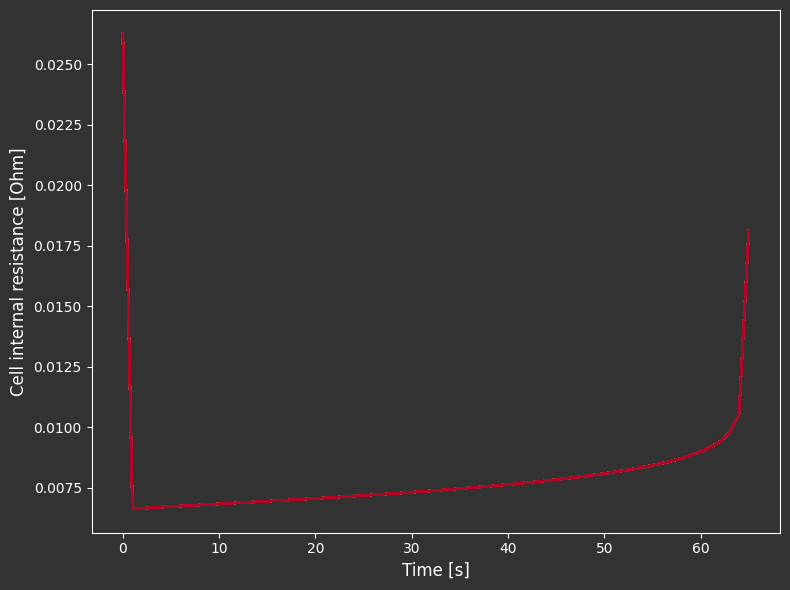

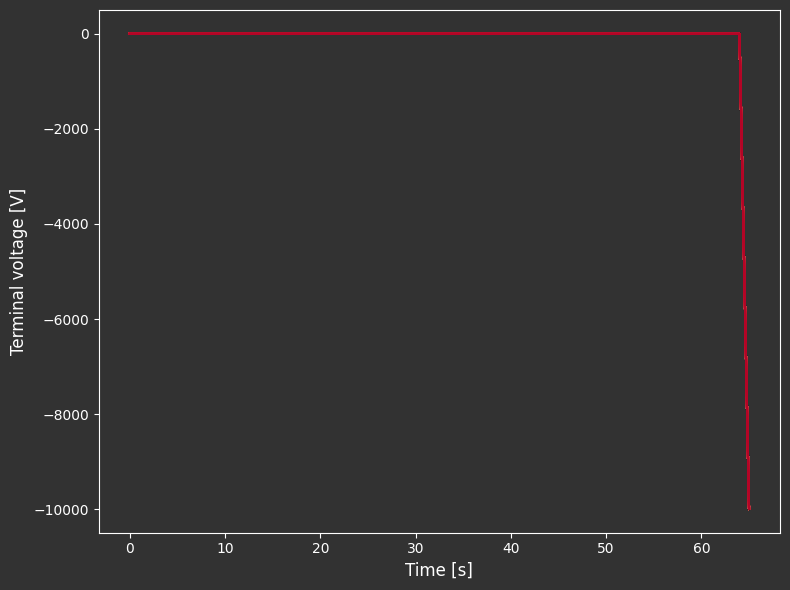

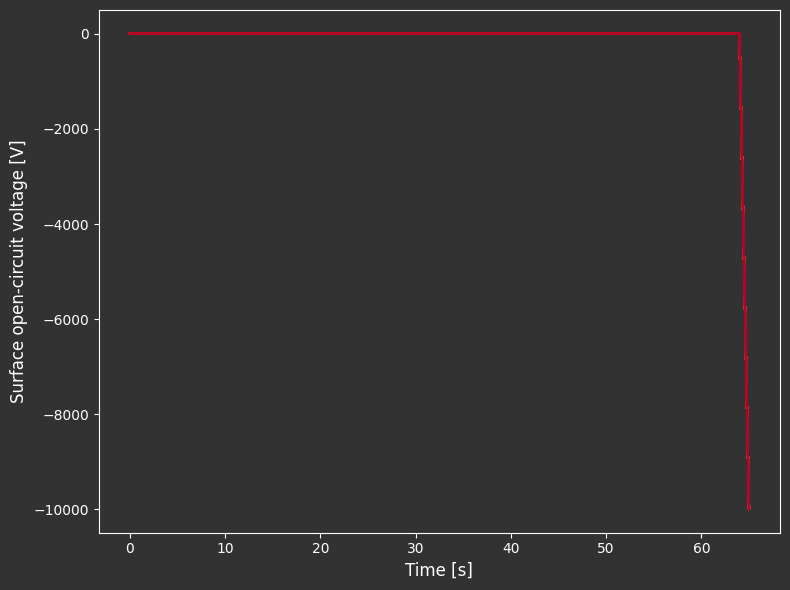

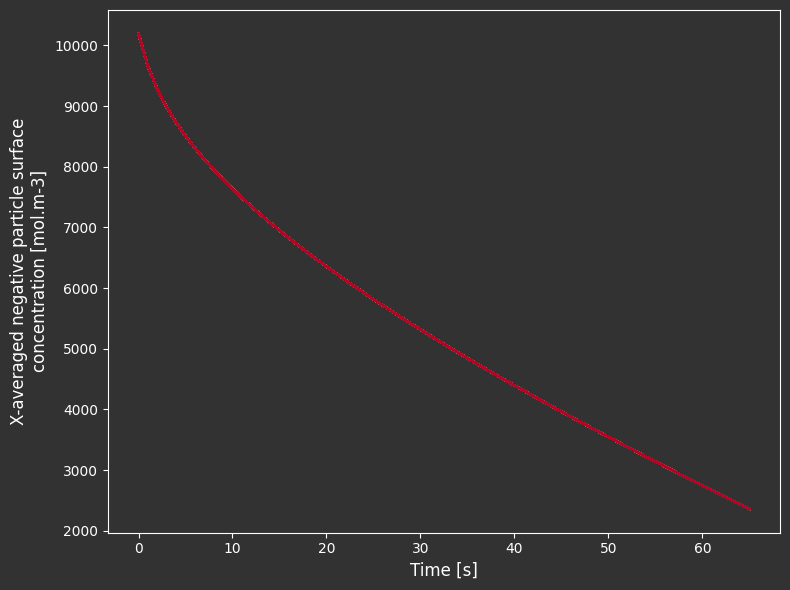

In [24]:
# Plot the pack and individual cell results
lp.plot_pack(output)
lp.plot_cells(output)
lp.show_plots()